## Przygotowanie

Przed rozpoczęciem pracy z notatnikiem proszę zmienić jego nazwę dodając na początku numer albumu, imię i nazwisko.
{nr_albumu}\_{imię}\_{nazwisko}\_{nazwa}

Po wykonaniu wszystkich zadań proszę przesłać wypełniony notatnik przez platformę TEAMS.

## Regresja logistyczna

Perceptron bazujący na modelu sztucznego neuronu jest dobrym algorytmem, aby wyrobić sobie pewną intuicję, jednak nie jest on powszechnie stosowany do rozwiązywania problemów klasyfikacji. Głównym problemem jest wykorzystywana w nim funkcja aktywacji oraz, w konsekwencji, sposób uczenia. Funkcja skokowa Heaviside'a jest nieróżniczkowalna w punkcie $x=0$, a jej pochodna wynosi $0$ w każdym innym punkcie. Powoduje to, że metody gradientowe (w tym metoda gradientu prostego) nie mogą być stosowane do optymalizacji wag. Wiele algorytmów, w tym implementowana regresja liniowa, wykorzystuje metody gradientowe do optymalizacji. Aby to było możliwe w przypadku perceptronu, należy zmienić funkcję aktywacji na taką, która będzie różniczkowalna w każdym punkcie.

### Funkcja sigmoidalna

Funkcją, która spełnia powyższe wymagania jest funkcja sigmoidalna, zwana również funkcją logistyczną. Dana jest wzorem:

$$f(x) = \frac{1}{1+e^{-x}}$$

Poniższy obraz przedstawia wykres funkcji sigmoidalnej.

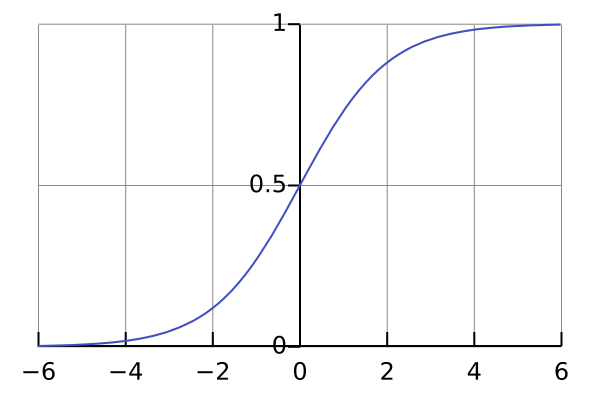

Tak jak w przypadku funkcji skokowej Heaviside'a, funkcja mapuje dowolną wartość rzeczywistą na wartości z przedziału $(0,1)$. Wartość funkcji może być rozumiana jako prawdopodobieństwo wyniku pozytywnego. Przykładowo, jeśli $f(x) = 0.9$, to prawdopodobieństwo $1$ jest równe $90\%$. Czyli jeśli mamy problem klasyfikacji binarnej, a $1$ oznacza np. obecność wirusa grypy w organiźmie, to możemy powiedzieć, że na $90\%$ jesteśmy chorzy na grypę. Warto również zauważyć, że funkcja logistyczna zmierza do $1$ dla wartości dodatnich, a dla wartości ujemnych zmierza do $0$. Zmiana predykcji jest w punkcie $0$, gdzie wartość funkcji wynosi $0.5$.

Zaletą funkcji sigmoidalnej jest łatwa do obliczenia pochodna:

$$f(x)' = f(x)(1-f(x))$$

Algorytm, który wykorzystuje tę funkcję aktywacji nazywany jest **regresją logistyczną**. Nazwa może być myląca i może sugerować, że służy on do rozwiązywania problemów regresji, ale w rzeczywistości wykorzystywany jest do problemów klasyfikacji.

Finalnie, nasza hipoteza będzie wyglądać następująco.

$$h_w(x) = f(\sum_{i=0}^{n}{w_ix_i})$$

$$s = \sum_{i=0}^{n}{w_ix_i}$$

$$f(s) = \frac{1}{1+e^{-s}}$$

### Funkcja błędu

Poznaliśmy już jedną funkcję błędu, która wykorzystywana była do obliczenia błędu regresji liniowej (i wielomianowej). W przypadku regresji logistycznej nie możemy z niej skorzystać, ponieważ regresja logistyczna spowoduje, że taka funkcja będzie miała wiele lokalnych minimum, a co za tym idzie, znalezienie optymalnego zestawu wag będzie bardzo trudne. W związku z tym, konieczne jest znalezienie innej funkcji błędu. Powszechna funkcja błędu, która jest wykorzystywana w algorytmie regresji logistycznej ma następującą formę.

$$
Cost(h_w(x), y) =
\begin{cases}
-log(h_w(x))        &   \mathrm{if} \ y=1,\\
-log(1 - h_w(x))    &   \mathrm{if} \ y=0
\end{cases}
$$

Gdzie $y$ jest prawdziwą wartością.

<table>
    <tr>
        <td> <img src="attachment:cost1.png" alt="Drawing" style=""/> </td>
        <td> <img src="attachment:cost0.png" alt="Drawing" style=""/> </td>
    </tr>
</table>

Czyli jeśli $y=0$, to funkcja kosztu będzie mieć wartość $0$, tylko jeśli hipoteza będzie mieć wartość $0$. Jeśli $h_w(x)$ zmierza do $1$, to funkcja kosztu zmierza do nieskończoności. 

Analogicznie, jeśli $y=1$, to funkcja kosztu będzie równa $0$ tylko, gdy hipoteza będzie równa $1$. Jeśli $h_w(x)$ będzie zmierzać do $0$, to wartość funkcji kosztu będzie zmierzać do nieskończoności.

Zapis powyższej funkcji błędu może zostać uproszczony do jednego równania:

$$Cost(h_w(x), y) = -y\:log(h_w(x)) - (1 - y)\:log(1 - h_w(x))$$

Dlaczego można tak zrobić? Zauważmy, że jeśli $y=0$, to pierwsza część równania się zeruje, zostaje jedynie druga. Natomiast jeśli $y=1$, to zeruje się druga część równania, zostawiając jedynie pierwszą.

### Trenowanie modelu

Wzór na funkcję błędu dla regresji logistycznej można zapisać jako:

$$J(w) = \frac{1}{m} \sum_{i=1}^{m}Cost(h_w(x^{(i)}),y^{(i)}) = - \frac{1}{m} [\sum_{i=1}^{m} y^{(i)} log(h_w(x^{(i)})) + (1 - y^{(i)}) log(1 - h_w(x^{(i)}))]$$

Dobór wag przeprowadzony zostanie z wykorzystaniem algorytmu gradientu prostego. Tak jak w przypadku algorytmu regresji liniowej, w każdej epoce obliczone zostaną nowe wagi, które powinny skutkować zmniejszeniem błędu. W algorytmie perceptronu wagi akutalizowane były po każdej próbce uczącej, natomiast tutaj po jednym przejściu zestawu uczącego. Istnieją różne warianty ilości próbek, po których wagi są aktualizowane, jednak dla uproszczenia wybieramy cały zbiór.

Dobra wiadomość jest taka, że proces aktualizacji wag wygląda praktycznie identycznie, jak miało to miejsce w przypadku algorytmu regresji liniowej. Pochodna funkcji błędu dla $j$-tej wagi ma postać: 

$$\frac{\partial J(w)}{\partial w_j} = \frac{1}{m} \sum^{m}_{i=1} (h_w(x^{(i)}) - y^{(i)})x_{j}^{(i)}$$

Zatem wagi akutalizujemy tak, jak robiliśmy to uprzednio:

$$w_j = w_j - \alpha \frac{\partial J(w)}{\partial w_j} = w_j - \frac{\alpha}{m} \sum^{m}_{i=1} (h_w(x^{(i)}) - y^{(i)})x_{j}^{(i)}$$

Proces aktualizacji wag wynika bezpośrednio z obliczenia pochodnej funkcji błędu względem wag. W tym notatniku nie będziemy przechodzić przez cały ten proces. Dla osób, które chcą poznać matematyczne detale, przekształcenia opisane są np. [tutaj](https://towardsdatascience.com/logistic-regression-from-scratch-69db4f587e17).

_Powyższy zapis jest w formie iteracyjnej, a w notaniku z regresją liniową był w formie macierzowej. Te dwa zapisy są równoznaczne i warto znać i rozumieć obie formy._

### Regresja logistyczna a perceptron

Powyższy algorytm w formie z sigmoidalną funkcją aktywacji bardzo często wykorzystywany jest jako podstawowy element wielowarstwowych sieci neuronowych. Jego dobre zrozumienie znacznie ułatwi zrozumienie sposobu działania sieci neuronowych. Porównując ze sobą działania algorytmu regresji logistycznej, a wcześniej implementowanego perceptronu, na pojedynczych neuronach nie widać róznic. Obie implementacje służą do rozwiązywania problemów klasyfikacji w zbiorach liniowo separowalnych. Ich celem jest wyznaczenie prostej separującej próbki pochodzące z różnych klas. Różnica pojawia się w momencie, gdy chcemy stworzyć strukturę złożoną z wielu neuronów. Wykorzystanie w tym celu perceptronu nie jest możliwe, ponieważ sieci neuronowe trenowane są najcześciej z wykorzystaniem algorytmu opartego o obliczenie gradientu funkcji błędu.

Struktury złożone z wielu neuronów mogą rozwiązywać problemy nieliniowo separowalne. Daje to duże możliwości i tłumaczy duże zainteresowanie sieciami neuronowymi. Innym sposobem na rozwiązanie problemu nieliniowo separowalnego może być rozwinięcie hipotezy o wielomianową formę, tak jak robiliśmy to w przypadku regresji wielomianowej.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import unittest

### Zadanie 1

Zaimplementuj opisany algorytm regresji logistycznej, który będzie skutecznie klasyfikował próbki z liniowo separowalnego zestawu danych. 

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [3]:
def hypothesis(X, w):
    return sigmoid(X @ w)

In [4]:
def cost_function(X, y, w):
    m = len(y)
    h = hypothesis(X, w)
    
    epsilon = 1e-10
    h = np.clip(h, epsilon, 1 - epsilon)
    
    cost = - (1 / m) * np.sum( y * np.log(h) + (1 - y) * np.log(1 - h) )
    
    return cost

In [5]:
def gradient(X, y, w):
    m = len(y)
    h = hypothesis(X, w)
    
    return (1 / m) * (X.T @ (h - y))

In [6]:
def update_weights(X, y, alpha, epochs, tol=1e-6):
    n = X.shape[1]
    w = np.zeros(n)
    cost_history = []
    weights_history = []

    prev_cost = float('inf')

    for t in range(epochs):
        grad = gradient(X, y, w)
        w -= alpha * grad
        
        cost = cost_function(X, y, w)
        cost_history.append(cost)
        weights_history.append(w.copy())

        if abs(prev_cost - cost) < tol:
            print(f"Uczenie zakończone po {t+1} epokach")
            break

        prev_cost = cost

    return w, cost_history, weights_history

In [7]:
def logistic_regression(X, y, alpha=0.1, epochs=1000, threshold=0.5):
    w, cost_history, weights_history = update_weights(X, y, alpha, epochs)
    y_pred = (hypothesis(X, w) >= threshold).astype(int)
    
    return w, y_pred, cost_history, weights_history

### Zadanie 2

Wczytaj zbiór danych znajdujący się w pliku Ankieta.csv, stwórz wykres próbek. Następnie stwórz 3 wykresy na których przedstawisz jak zmieniała się granica decyzyjna zaimplementowanego algorytmu regresji logistycznej na przestrzeni epok. Porównaj wynik z algorytmem perceptronu (zarówno czas działania jak i jakość wyznaczonej granicy decyzyjnej)

**Uwaga:** Przed podaniem danych na wejście klasyfikatora należy je znormalizować. Zbyt duże wartości powodują, że logarytmy liczą się niepoprawnie (log(0) daje NaN). Dla zainteresowanych wyjaśnienie dostępne jest [tutaj](https://stackoverflow.com/questions/35419882/cost-function-in-logistic-regression-gives-nan-as-a-result)

In [8]:
df = pd.read_csv("Ankieta.csv")
df['Plec'] = df['Plec'].map({'Kobieta': 1, 'Mezczyzna' : 0})
df.head()

,Waga,Wzrost,Plec
0,55,160,1
1,78,180,0
2,55,150,1
3,99,196,0
4,90,180,0


In [9]:
X = df[['Waga', 'Wzrost']].values
y = df['Plec'].values

<Axes: xlabel='Waga', ylabel='Wzrost'>

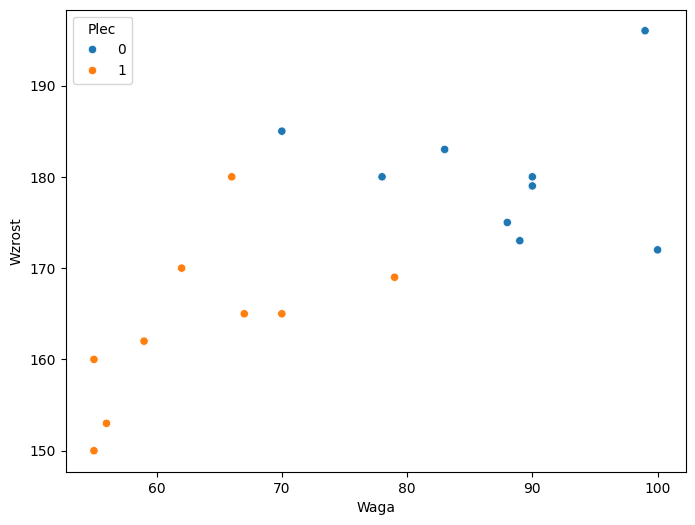

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Waga', y='Wzrost', hue='Plec')

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = np.hstack((np.ones((X_scaled.shape[0], 1)), X_scaled))

Text(0.5, 1.0, 'Próbki danych (po standaryzacji)')

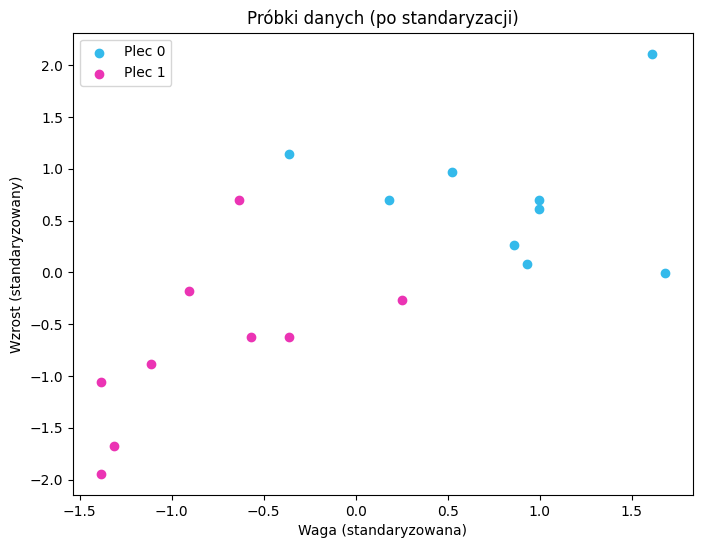

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(X_scaled[y==0][:,1], X_scaled[y==0][:,2], color='#34baeb', label='Plec 0')
plt.scatter(X_scaled[y==1][:,1], X_scaled[y==1][:,2], color='#eb34b4', label='Plec 1')

plt.xlabel('Waga (standaryzowana)')
plt.ylabel('Wzrost (standaryzowany)')
plt.legend()
plt.title('Próbki danych (po standaryzacji)')

#### Testy

In [13]:
w_final, y_pred, cost_hist, weights_hist = logistic_regression(
    X_scaled, y, alpha=0.5, epochs=200, threshold=0.5
)

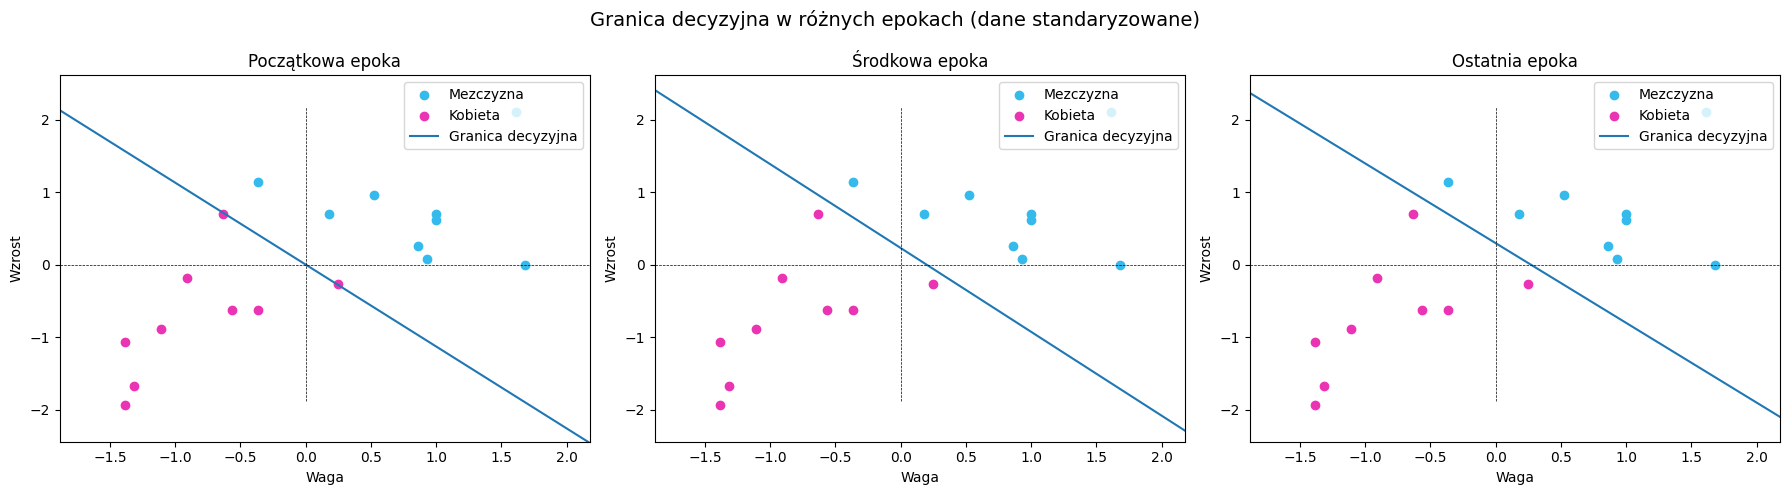

In [14]:
epochs_to_plot = [0, len(weights_hist)//2, -1]
titles = ['Początkowa epoka', 'Środkowa epoka', 'Ostatnia epoka']

color_men = '#34baeb'
color_women = '#eb34b4'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, idx, title in zip(axes, epochs_to_plot, titles):
    w = weights_hist[idx]  # wektor wag z wybranej epoki

    x1_min, x1_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    x2_min, x2_max = X_scaled[:, 2].min() - 0.5, X_scaled[:, 2].max() + 0.5
    x1 = np.linspace(x1_min, x1_max, 100)
    
    # granica decyzyjna: w0 + w1*x1 + w2*x2 = 0 => x2 = -(w0 + w1*x1)/w2
    x2 = -(w[0] + w[1]*x1)/w[2]
    
    ax.scatter(X_scaled[y == 0][:, 1], X_scaled[y == 0][:, 2], label='Mezczyzna', color=color_men)
    ax.scatter(X_scaled[y == 1][:, 1], X_scaled[y == 1][:, 2], label='Kobieta', color=color_women)
    
    # granica decyzyjna
    ax.plot(x1, x2, label='Granica decyzyjna')
    
    # osie pomocnicze
    zeros = np.zeros_like(x1)
    ax.plot(x1, zeros, c='black', linewidth=0.5, linestyle='--')
    ax.plot(zeros, x1, c='black', linewidth=0.5, linestyle='--')
    
    ax.set_xlabel('Waga')
    ax.set_ylabel('Wzrost')
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min, x2_max)
    ax.set_title(title)
    ax.legend()

fig.suptitle('Granica decyzyjna w różnych epokach (dane standaryzowane)', fontsize=14)
plt.tight_layout()
plt.show()

#### Porównanie z działaniem perceptronu

In [15]:
def perceptron_train(X, y, alpha=0.01, epochs=100):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0
    #w = np.random.uniform(-0.01, 0.01, size=n_features)
    #b = np.random.uniform(-0.01, 0.01)

    epoch_history = []

    for epoch in range(epochs):
        errors = 0
        
        for i in range(n_samples):
            linear_output = np.dot(X[i], w) + b
            if linear_output >= 0:
                y_pred = 1
            else:
                y_pred = 0
                
            error = y[i] - y_pred
            if error != 0:
                errors += 1
                
            w += alpha * error * X[i]
            b += alpha * error
        epoch_history.append((w.copy(), b))

        if errors == 0:
            print(f"Uczenie zakończone po {epoch+1} epokach")
            break

    return w, b, epoch_history

In [16]:
start = time.time()
w_lr, y_pred_lr, cost_hist, weights_hist = logistic_regression(X_scaled, y, alpha=0.5, epochs=2000)
end = time.time()

print("Czas uczenia regresji logistycznej:", end - start)

Czas uczenia regresji logistycznej: 0.1600022315979004


In [17]:
X_perc = X_scaled[:, 1:]  # usuwamy bias do perceptronu

start = time.time()
w_p, b_p, history_p = perceptron_train(X_perc, y, alpha=0.00001, epochs=2000)
end = time.time()

print("Czas uczenia perceptronu:", end - start)

Uczenie zakończone po 4 epokach
Czas uczenia perceptronu: 0.0019960403442382812


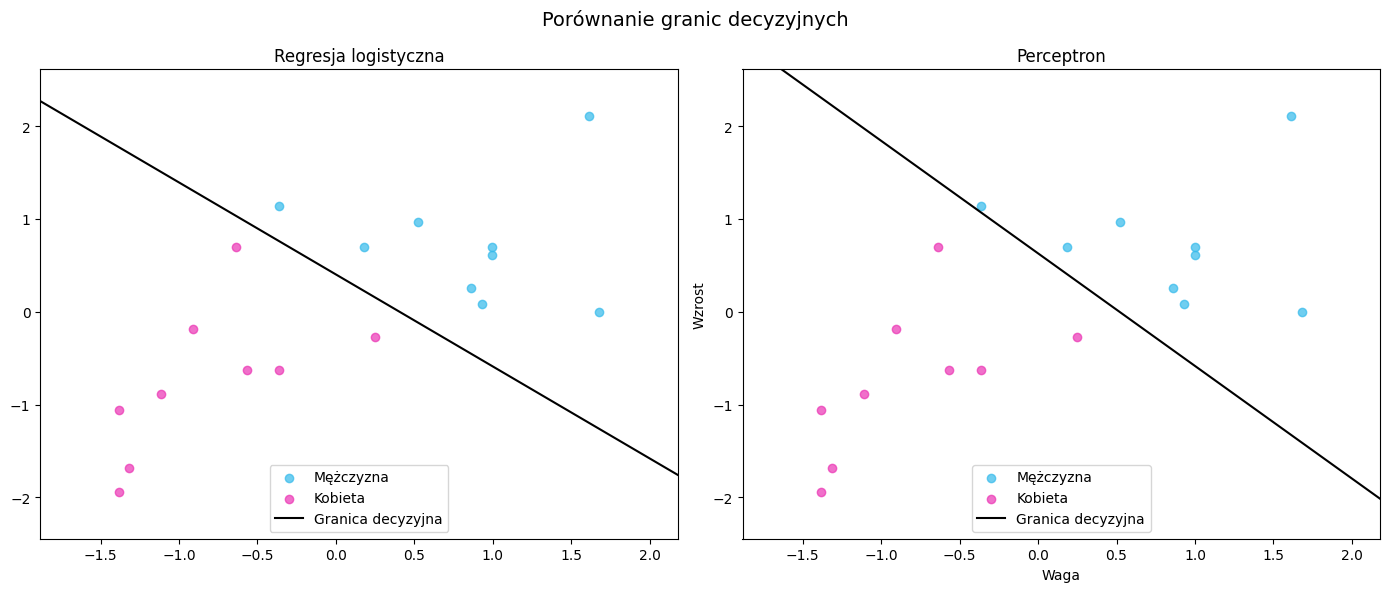

In [18]:
X_lr = X_scaled
X_p = X_scaled[:, 1:]

x1_min = X_p[:, 0].min() - 0.5
x1_max = X_p[:, 0].max() + 0.5
x2_min = X_p[:, 1].min() - 0.5
x2_max = X_p[:, 1].max() + 0.5

x1 = np.linspace(x1_min, x1_max, 100)

x2_lr = -(w_lr[0] + w_lr[1]*x1) / w_lr[2]
x2_p = -(w_p[0]*x1 + b_p) / w_p[1]


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
color_men = '#34baeb'
color_women = '#eb34b4'

# ===== REGRESJA LOGISTYCZNA =====
axes[0].scatter(X_p[y==0][:,0], X_p[y==0][:,1], color=color_men, label='Mężczyzna', alpha=0.7)
axes[0].scatter(X_p[y==1][:,0], X_p[y==1][:,1], color=color_women, label='Kobieta', alpha=0.7)
axes[0].plot(x1, x2_lr, color='black', label='Granica decyzyjna')
axes[0].set_title('Regresja logistyczna')
axes[0].set_xlim(x1_min, x1_max)
axes[0].set_ylim(x2_min, x2_max)
axes[1].set_xlabel('Waga')
axes[1].set_ylabel('Wzrost')
axes[0].legend()

# ===== PERCEPTRON =====
axes[1].scatter(X_p[y==0][:,0], X_p[y==0][:,1], color=color_men, label='Mężczyzna', alpha=0.7)
axes[1].scatter(X_p[y==1][:,0], X_p[y==1][:,1], color=color_women, label='Kobieta', alpha=0.7)
axes[1].plot(x1, x2_p, color='black', label='Granica decyzyjna')
axes[1].set_title('Perceptron')
axes[1].set_xlim(x1_min, x1_max)
axes[1].set_ylim(x2_min, x2_max)
axes[1].set_xlabel('Waga')
axes[1].set_ylabel('Wzrost')
axes[1].legend()

fig.suptitle('Porównanie granic decyzyjnych', fontsize=14)
plt.tight_layout()

Text(0.5, 1.0, 'Funkcja kosztu – regresja logistyczna')

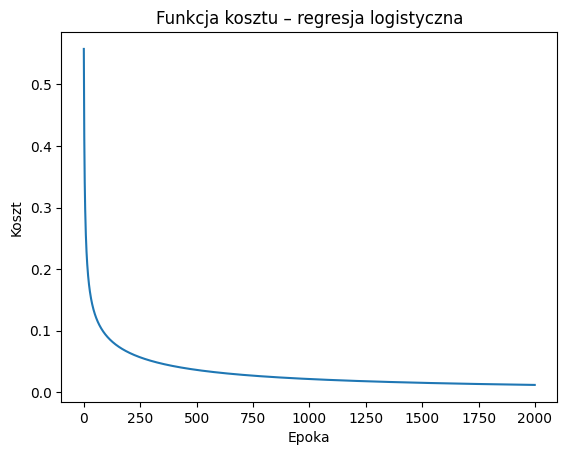

In [19]:
plt.plot(cost_hist)
plt.xlabel("Epoka")
plt.ylabel("Koszt")
plt.title("Funkcja kosztu – regresja logistyczna")

Perceptron zakończył uczenie znacznie szybciej (prawie stukrotnie), gdyż jego celem jest znalezienie dowolnej granicy liniowo separującej dane. Regresja logistyczna kontynuuje poprawianie wag, pomimo poprawnej separacji klas - wynika to z ustawionego warunku zmiany funkcji kosztu i lepszego dopasowania wartości probabilistycznych. Czas ten jest więc naturalnie dłuższy gdyż algorytm wykorzystał wszystkie epoki do uczenia. Można zmodyfikować funkcję uczenia regresji liniowej tak aby od razu dawała nam wynik klasyfikacji, aby ujednolicić rodzaj sprawdzanego błędu.

In [20]:
def update_weights_err(X, y, alpha, epochs, tol=1e-6):
    n = X.shape[1]
    w = np.zeros(n)

    cost_history = []
    weights_history = []
    errors_history = []

    prev_cost = float('inf')

    for t in range(epochs):
        grad = gradient(X, y, w)
        w -= alpha * grad
        cost = cost_function(X, y, w)
        cost_history.append(cost)
        weights_history.append(w.copy())

        # błąd klasyfikacji (jak w perceptronie)
        y_pred = (hypothesis(X, w) >= 0.5).astype(int)
        errors = np.sum(y_pred != y)
        errors_history.append(errors)

        # warunek stopu jak w perceptronie
        if errors == 0:
            print(f"Uczenie zakończone (brak błędów) po {t+1} epokach")
            break

        prev_cost = cost

    return w, cost_history, weights_history, errors_history

def logistic_regression_err(X, y, alpha=0.1, epochs=1000, threshold=0.5):
    w, cost_history, weights_history, errors_history = update_weights_err(
        X, y, alpha, epochs
    )

    y_pred = (hypothesis(X, w) >= threshold).astype(int)

    return w, y_pred, cost_history, weights_history, errors_history

In [21]:
start = time.time()
w_lr, y_pred_lr, cost_hist, weights_hist, errors_hist = logistic_regression_err(X_scaled, y, alpha=0.5, epochs=2000)
end = time.time()

print("Czas uczenia regresji logistycznej:", end - start)

Uczenie zakończone (brak błędów) po 13 epokach
Czas uczenia regresji logistycznej: 0.002992391586303711


In [22]:
X_perc = X_scaled[:, 1:]  # usuwamy bias do perceptronu

start = time.time()
w_p, b_p, history_p = perceptron_train(X_perc, y, alpha=0.00001, epochs=2000)
end = time.time()

print("Czas uczenia perceptronu:", end - start)

Uczenie zakończone po 4 epokach
Czas uczenia perceptronu: 0.001993894577026367


##### W tym wypadku porównanie jest bardziej zasadne. Regresja logistyczna osiągnęłą zerowy błąd klasyfikacji po 13 epokach, gdy perceptron zakończył proces uczenia już po 4 epokach. W tym przypadku dobrze widoczne jest szybsze działanie perceptronu, do czego przyczyniać się może jego prostsza budowa.

### Zadanie 3

Wykorzystaj stworzony algorym w celu znalezienia granicy decyzyjnej będącej płaszczyzną w trójwymiarowej przestrzeni. Zbiór danych znajduje się w pliku o nazwie 3D_perceptron.csv. Stwórz wykresy analogicznie jak w zadaniu 2. Porównaj wynik z algorytmem perceptronu.

In [23]:
df_3d = pd.read_csv("3D_perceptron.csv")

df_3d.head()

,x1,x2,x3,y
0,2.725907,10.023840,11.224807,1
1,0.680593,15.299426,14.318900,1
2,0.215521,12.710218,11.106429,1
3,-1.739506,-15.825530,-17.599468,0
4,-2.219526,9.772773,10.841995,1


In [24]:
X = df_3d.iloc[:, :-1].values
y = df_3d.iloc[:, -1].values

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)
X_scaled = np.hstack((np.ones((X_norm.shape[0], 1)), X_norm))

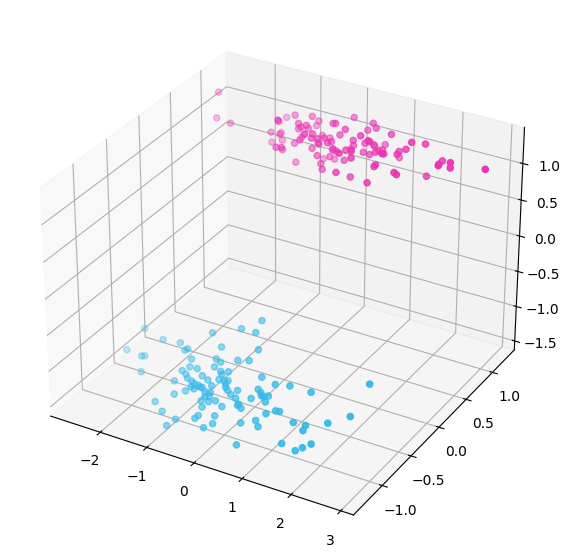

In [25]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_norm[y == 0][:, 0],
    X_norm[y == 0][:, 1],
    X_norm[y == 0][:, 2],
    label='Klasa 0',
    color='#34baeb'
)

ax.scatter(
    X_norm[y == 1][:, 0],
    X_norm[y == 1][:, 1],
    X_norm[y == 1][:, 2],
    label='Klasa 1',
    color='#eb34b4'
)

In [26]:
start = time.time()
w_lr, y_pred_lr, cost_hist, weights_hist = logistic_regression(X_scaled, y, alpha=0.5, epochs=2000)
end = time.time()

print("Czas uczenia regresji logistycznej:", end - start)

Uczenie zakończone po 1170 epokach
Czas uczenia regresji logistycznej: 0.13099288940429688


In [27]:
start = time.time()
w_p, b_p, history_p = perceptron_train(X_scaled, y, alpha=0.01, epochs=2000)
end = time.time()

print("Czas uczenia perceptronu:", end - start)

Uczenie zakończone po 2 epokach
Czas uczenia perceptronu: 0.011002063751220703


In [28]:
y_pred = np.array([1 if np.dot(X_scaled[i], w_p) + b_p >= 0 else 0 for i in range(len(y))])
errors = np.sum(y_pred != y)
accuracy = 1 - errors/len(y)

print(f"Liczba błędów: {errors}")
print(f"Dokładność: {accuracy*100:.2f}%")

Liczba błędów: 0
Dokładność: 100.00%


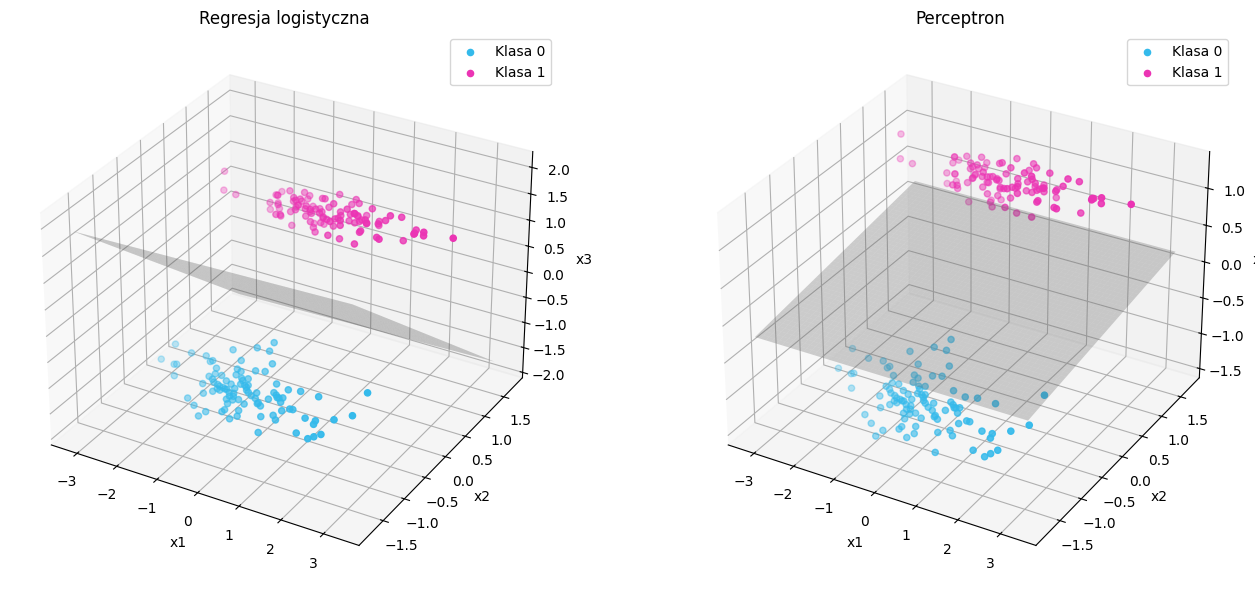

In [29]:
xx, yy = np.meshgrid(
    np.linspace(X_norm[:,0].min()-0.5, X_norm[:,0].max()+0.5, 50),
    np.linspace(X_norm[:,1].min()-0.5, X_norm[:,1].max()+0.5, 50)
)

fig = plt.figure(figsize=(14,6))

# --- Regresja logistyczna ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(X_norm[y==0][:,0], X_norm[y==0][:,1], X_norm[y==0][:,2], color='#34baeb', label='Klasa 0')
ax1.scatter(X_norm[y==1][:,0], X_norm[y==1][:,1], X_norm[y==1][:,2], color='#eb34b4', label='Klasa 1')
zz_lr = -(w_lr[0] + w_lr[1]*xx + w_lr[2]*yy) / w_lr[3]
ax1.plot_surface(xx, yy, zz_lr, alpha=0.3, color='gray')
ax1.set_title("Regresja logistyczna")
ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.set_zlabel('x3')
ax1.legend()

# --- Perceptron ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(X_norm[y==0][:,0], X_norm[y==0][:,1], X_norm[y==0][:,2], color='#34baeb', label='Klasa 0')
ax2.scatter(X_norm[y==1][:,0], X_norm[y==1][:,1], X_norm[y==1][:,2], color='#eb34b4', label='Klasa 1')
zz_p = -(b_p + w_p[0]*xx + w_p[1]*yy) / w_p[2]
ax2.plot_surface(xx, yy, zz_p, alpha=0.3, color='gray')
ax2.set_title("Perceptron")
ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_zlabel('x3')
ax2.legend()

plt.tight_layout()

Obie granice poprawnie separują klasy - w przypadku perceptronu potwierdzono to policzonym ccuracy wynoszącym 100%. Widoczne jest natomiast, że płaszczyzny różnią się od siebie i w przypadku nowych danych mogłyby inaczej przydzielać klasy.

### Zadanie 4

Zaimplementu test jednostkowy sprawdzający czy błąd spada wraz z epokami.

In [30]:
class UpdateWeightsTest(unittest.TestCase):

    def test_cost_decreases(self):
        df = pd.read_csv("3D_perceptron.csv")
        X = df[['x1', 'x2', 'x3']].values
        y = df['y'].values

        # Parametry
        alpha = 0.01
        epochs = 500

        w, cost_history, weights_history = update_weights(X, y, alpha, epochs)

        # Sprawdzenie, czy koszt nie rośnie (koszt powinien maleć)
        self.assertTrue(all(i >= j for i, j in zip(cost_history, cost_history[1:])), msg="Koszt nie spada w kolejnych epokach")

unittest.main(argv=[''], verbosity=2, exit=False)

test_cost_decreases (__main__.UpdateWeightsTest) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.061s

OK


In [31]:
# Dane standaryzowane
class UpdateWeightsTest(unittest.TestCase):

    def test_cost_decreases(self):
        df = pd.read_csv("3D_perceptron.csv")
        X = df[['x1', 'x2', 'x3']].values
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        y = df['y'].values

        # Parametry
        alpha = 0.01
        epochs = 500

        w, cost_history, weights_history = update_weights(X_scaled, y, alpha, epochs)

        # Sprawdzenie, czy koszt nie rośnie (koszt powinien maleć)
        self.assertTrue(all(i >= j for i, j in zip(cost_history, cost_history[1:])), msg="Koszt nie spada w kolejnych epokach")

unittest.main(argv=[''], verbosity=2, exit=False)

test_cost_decreases (__main__.UpdateWeightsTest) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.050s

OK


### Zadanie 5

Zaproponuj i oblicz miarę skuteczności algorytmu regresji logistycznej. Wynik należy podać w % (ile próbek poprawnie zaklasyfikował algorytm) 

In [32]:
df = pd.read_csv("Ankieta.csv")
df['Plec'] = df['Plec'].map({'Kobieta': 1, 'Mezczyzna' : 0})
X = df[['Waga', 'Wzrost']].values
y = df['Plec'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = np.hstack((np.ones((X_scaled.shape[0], 1)), X_scaled))

In [33]:
# Przypomnienie
def logistic_regression_err(X, y, alpha=0.1, epochs=1000, threshold=0.5):
    w, cost_history, weights_history, errors_history = update_weights_err(
        X, y, alpha, epochs
    )

    y_pred = (hypothesis(X, w) >= threshold).astype(int)

    return w, y_pred, cost_history, weights_history, errors_history

In [34]:
def accuracy(y_true, y_pred):
    correct = np.sum(y_true.flatten() == y_pred.flatten())
    total = len(y_true)
    return (correct / total) * 100

In [35]:
# Parametry do testów
alphas = [0.0001, 0.05, 0.1, 0.5, 5]
epochs_list = [100, 500, 1000]

for alpha in alphas:
    print(f"alpha={alpha}:")
    for epochs in epochs_list:
        w, y_pred, cost_history, weights_history, errors_history = logistic_regression_err(
            X_scaled, y, alpha=alpha, epochs=epochs, threshold=0.5
        )
        acc = accuracy(y, y_pred)
        print(f"epochs={epochs} -> Accuracy: {acc:.2f}%")
    

alpha=0.0001:
epochs=100 -> Accuracy: 94.44%
epochs=500 -> Accuracy: 94.44%
epochs=1000 -> Accuracy: 94.44%
alpha=0.05:
epochs=100 -> Accuracy: 94.44%
Uczenie zakończone (brak błędów) po 127 epokach
epochs=500 -> Accuracy: 100.00%
Uczenie zakończone (brak błędów) po 127 epokach
epochs=1000 -> Accuracy: 100.00%
alpha=0.1:
Uczenie zakończone (brak błędów) po 64 epokach
epochs=100 -> Accuracy: 100.00%
Uczenie zakończone (brak błędów) po 64 epokach
epochs=500 -> Accuracy: 100.00%
Uczenie zakończone (brak błędów) po 64 epokach
epochs=1000 -> Accuracy: 100.00%
alpha=0.5:
Uczenie zakończone (brak błędów) po 13 epokach
epochs=100 -> Accuracy: 100.00%
Uczenie zakończone (brak błędów) po 13 epokach
epochs=500 -> Accuracy: 100.00%
Uczenie zakończone (brak błędów) po 13 epokach
epochs=1000 -> Accuracy: 100.00%
alpha=5:
Uczenie zakończone (brak błędów) po 2 epokach
epochs=100 -> Accuracy: 100.00%
Uczenie zakończone (brak błędów) po 2 epokach
epochs=500 -> Accuracy: 100.00%
Uczenie zakończone (brak 

### Zadanie 6

Jak współczynnik uczenia alpha wypływa na wynik oraz ilość epok jakie należy zastosować? Porównaj minimum 5 różnych wartości współczynnika alpha oraz sformułuj wnioski.

W Zadaniu 5. do przetestowania skuteczności algorytmu wykorzystano różne kombinacje wartości alpha oraz liczby epok. Przy zbyt małych wartościach współczynnika uczenia model regresji logistycznej nie jest w stanie osiągnąć 100% dokładności - zwiększanie liczby epok nie przynosi oczekiwanego rezultatu. Zbyt małe alpha może więc uniemożliwić osiągnięcie pełnej skuteczności. Stopniowe zwiększanie alphy pokazało, że przy małej liczbie epok dalej niektóre rekordy zostają źle sklasyfikowane, natomiast pomaga zwiększenie liczby epok. Dla tych danych przetestowano także alpha=5, które pozwoliło uzyskać 100% accuracy w zaledwie 2 epokach. Jednak warto uważać na takie lub wyższe wartości w przypadku danych mniej odseparowanych (trudniejszych do klasyfikacji)